# Evo 2 Ablation Study — Local / NVIDIA NIM Runner

Runs the 4-mode context window ablation using the
[NVIDIA NIM Evo 2 API](https://build.nvidia.com/arc/evo2-40b) — no GPU required.

**4 conditions**:
- `A` NO_CONTEXT — 4 bp seed only
- `B` UPSTREAM_ONLY — upstream flanking sequence as prompt
- `C` FULL_CONTEXT — upstream prompt (downstream available for scoring context)
- `D` TAGGED_FULL — semantic type tags + upstream prompt

**Before running**: get an API key at [build.nvidia.com](https://build.nvidia.com/settings/api-keys)
and set it in the Config cell.

**NVIDIA NIM endpoint used**:
- `POST https://health.api.nvidia.com/v1/biology/arc/{model}/generate`
  - `sequence` — the prompt
  - `num_tokens` — tokens to generate
  - `enable_sampled_probs: true` — returns per-token probabilities used for log-prob scoring
  - Context limit: **1,000,000 bp** (no trimming needed)

## 1. Install Dependencies

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'requests', 'pydantic', 'ViennaRNA',
                'pandas', 'matplotlib', 'seaborn', 'scipy',
                'python-dotenv'], check=True)
print('Dependencies installed.')

## 2. Config — Edit These Values

In [ ]:
import os
from pathlib import Path
from dotenv import load_dotenv

# Load .env from project root (one level up from notebooks/)
load_dotenv(Path("../.env"))

# --- NVIDIA NIM API key ---
# Set NVIDIA_API_KEY in .env (see .env.example)
NVIDIA_API_KEY = os.environ.get("NVIDIA_API_KEY", "")
if not NVIDIA_API_KEY:
    raise EnvironmentError("NVIDIA_API_KEY not set — add it to .env in the project root")

# --- Model variant ---
# 'evo2-40b'  — most capable (recommended)
# 'evo2-7b'   — faster, cheaper
# 'evo2-20b'  — middle ground
NVIDIA_MODEL = "evo2-7b"

# --- Path to UCF file ---
UCF_PATH = "../data/raw/Eco1C1G1T1.UCF.json"  # relative to this notebook

# --- Gate to ablate ---
GATE_NAME = "A1_AmtR"

# --- Generation parameters ---
N_CANDIDATES = 10     # per part per mode; use 50-100 for real runs
TEMPERATURE  = 0.8    # passed as top_p to NVIDIA API (nucleus sampling)
TOP_K        = 4

# --- Output directory ---
OUTPUT_DIR = Path("../results/ablation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Config OK")
print(f"  model:  {NVIDIA_MODEL}")
print(f"  gate:   {GATE_NAME}")
print(f"  n:      {N_CANDIDATES} candidates/mode")
print(f"  output: {OUTPUT_DIR.resolve()}")

## 3. Source Code (inlined from repo)

In [ ]:
# ── part_spec.py ────────────────────────────────────────────────
from pydantic import BaseModel, Field, field_validator
from typing import Optional, List
from enum import Enum


class PartType(str, Enum):
    PROMOTER   = "promoter"
    RBS        = "rbs"
    CDS        = "cds"
    TERMINATOR = "terminator"
    OPERATOR   = "operator"
    SPACER     = "spacer"


class HostOrganism(str, Enum):
    ECOLI_K12     = "ecoli_k12"
    ECOLI_BL21    = "ecoli_bl21"
    SACCHAROMYCES = "saccharomyces_cerevisiae"


class PartConstraints(BaseModel):
    min_length:        Optional[int]   = None
    max_length:        Optional[int]   = None
    strength_target:   Optional[str]   = None
    inducible_by:      Optional[str]   = None
    repressible_by:    Optional[str]   = None
    gc_content_min:    Optional[float] = None
    gc_content_max:    Optional[float] = None


class PartSpec(BaseModel):
    part_id:            str
    part_type:          PartType
    host:               HostOrganism
    functional_role:    str
    upstream_context:   str
    downstream_context: str
    constraints:        PartConstraints = Field(default_factory=PartConstraints)
    circuit_position:   int
    circuit_total:      int
    reference_seq:      Optional[str] = None
    sbol_component_id:  Optional[str] = None

    @field_validator("upstream_context", "downstream_context", "reference_seq", mode="before")
    @classmethod
    def validate_and_normalize_dna(cls, v):
        if v is None:
            return v
        v = v.upper().strip()
        invalid = set(v) - set("ACGT")
        if invalid:
            raise ValueError(f"Invalid DNA characters: {invalid}")
        return v

    def gc_content(self, sequence: Optional[str] = None) -> float:
        seq = sequence or self.reference_seq or ""
        if not seq:
            return 0.0
        return (seq.count("G") + seq.count("C")) / len(seq)


print("Schema loaded.")

Schema loaded.


In [ ]:
# ── cello_parser.py ─────────────────────────────────────────────
import json


_UCF_TYPE_TO_PART_TYPE = {
    "promoter":   PartType.PROMOTER,
    "rbs":        PartType.RBS,
    "cds":        PartType.CDS,
    "terminator": PartType.TERMINATOR,
    "ribozyme":   PartType.SPACER,
    "scar":       PartType.SPACER,
    "operator":   PartType.OPERATOR,
}

_UCF_TYPE_TO_ROLE = {
    "promoter":   "transcription_promoter",
    "rbs":        "ribosome_binding_site",
    "cds":        "coding_sequence",
    "terminator": "transcription_terminator",
    "ribozyme":   "translational_insulator",
    "scar":       "assembly_scar",
    "operator":   "operator_binding_site",
}


def _clean_seq(seq):
    return seq.upper().strip()

def _build_parts_map(ucf_data):
    return {p["name"]: p for p in ucf_data if p.get("collection") == "parts"}

def _get_cassette_components(structure):
    for device in structure.get("devices", []):
        if "cassette" in device["name"]:
            return device["components"]
    return []

def _infer_host(ucf_data):
    header = next((x for x in ucf_data if x.get("collection") == "header"), {})
    org = header.get("organism", "").lower()
    if "saccharomyces" in org: return HostOrganism.SACCHAROMYCES
    if "bl21" in org:          return HostOrganism.ECOLI_BL21
    return HostOrganism.ECOLI_K12

def _strength_label(ucf_type, params):
    if ucf_type == "terminator":
        v = params.get("terminator_strength")
        if v is not None:
            return "high" if v > 100 else "medium" if v > 10 else "low"
    if ucf_type == "ribozyme":
        v = params.get("ribozyme_efficiency")
        if v is not None:
            return "high" if v >= 0.9 else "medium" if v >= 0.5 else "low"
    return None

def _build_constraints(part):
    params = {p["name"]: p["value"] for p in part.get("parameters", [])}
    return PartConstraints(strength_target=_strength_label(part.get("type"), params))


def parse_ucf(ucf_path) -> List[PartSpec]:
    with open(ucf_path) as f:
        ucf_data = json.load(f)
    parts_map = _build_parts_map(ucf_data)
    host = _infer_host(ucf_data)
    structures = [x for x in ucf_data if x.get("collection") == "structures"]
    all_cassettes = [
        (s, _get_cassette_components(s))
        for s in structures
        if _get_cassette_components(s)
    ]
    circuit_total = sum(len(c) for _, c in all_cassettes)
    specs, global_pos = [], 0
    for structure, components in all_cassettes:
        gate_name = structure["name"].replace("_structure", "")
        seqs = [
            _clean_seq(parts_map[n]["dnasequence"]) if n in parts_map else ""
            for n in components
        ]
        for i, comp_name in enumerate(components):
            part = parts_map.get(comp_name)
            if part is None:
                global_pos += 1
                continue
            ucf_type = part.get("type", "")
            specs.append(PartSpec(
                part_id=f"{gate_name}__{comp_name}",
                part_type=_UCF_TYPE_TO_PART_TYPE.get(ucf_type, PartType.SPACER),
                host=host,
                functional_role=_UCF_TYPE_TO_ROLE.get(ucf_type, "unknown"),
                upstream_context="".join(seqs[:i]),
                downstream_context="".join(seqs[i + 1:]),
                reference_seq=_clean_seq(part["dnasequence"]),
                constraints=_build_constraints(part),
                circuit_position=global_pos,
                circuit_total=circuit_total,
                sbol_component_id=comp_name,
            ))
            global_pos += 1
    return specs


print("Parser loaded.")

Parser loaded.


In [ ]:
# ── types.py ────────────────────────────────────────────────
from dataclasses import dataclass
from enum import Enum


class GenerationMode(str, Enum):
    NO_CONTEXT    = "no_context"
    UPSTREAM_ONLY = "upstream_only"
    FULL_CONTEXT  = "full_context"
    TAGGED_FULL   = "tagged_full"


@dataclass
class GeneratedSequence:
    sequence:  str
    log_prob:  float
    mode:      GenerationMode
    part_spec: PartSpec
    rank:      Optional[int] = None

    def __len__(self):
        return len(self.sequence)

    def gc_content(self) -> float:
        seq = self.sequence.upper()
        return (seq.count("G") + seq.count("C")) / len(seq) if seq else 0.0


print("Generation types loaded.")

Generation types loaded.


In [33]:
# ── NVIDIA NIM Evo2 generator ──────────────────────────────────────────────
import requests
import time
import math

# NVIDIA NIM base URL — model name is part of the path
_NVIDIA_BASE = "https://health.api.nvidia.com/v1/biology/arc"

# Fallback seed when upstream context is empty (first part in a cassette)
_EMPTY_CONTEXT_SEED = "ACGT"

PART_TYPE_TAGS = {
    PartType.PROMOTER:   "<promoter>",
    PartType.RBS:        "<rbs>",
    PartType.CDS:        "<cds>",
    PartType.TERMINATOR: "<terminator>",
    PartType.OPERATOR:   "<operator>",
    PartType.SPACER:     "<spacer>",
}

STRENGTH_TAGS = {
    "low":    "<strength_low>",
    "medium": "<strength_medium>",
    "high":   "<strength_high>",
}


class NvidiaEvo2Generator:
    """
    Calls the NVIDIA NIM Evo 2 API for sequence generation and scoring.

    Endpoint: POST https://health.api.nvidia.com/v1/biology/arc/{model}/generate
    Auth:     Authorization: Bearer <API_KEY>

    Log-prob is computed from per-token sampled probabilities returned by the
    API (enable_sampled_probs=true) — no separate scoring endpoint needed.
    Context limit is 1,000,000 bp so no prompt trimming is required.
    """

    def __init__(self, api_key: str = None, model: str = None,
                 retry_delay: float = 2.0, max_retries: int = 3):
        self.api_key = api_key or NVIDIA_API_KEY
        self.model   = model or NVIDIA_MODEL
        self.url     = f"{_NVIDIA_BASE}/{self.model}/generate"
        self.retry_delay = retry_delay
        self.max_retries = max_retries
        self._session = requests.Session()
        self._session.headers.update({
            "Authorization": f"Bearer {self.api_key}",
            "Content-Type":  "application/json",
        })
        print(f"NvidiaEvo2Generator initialized")
        print(f"  model: {self.model}")
        print(f"  url:   {self.url}")

    def _post(self, payload: dict) -> dict:
        """POST to the generate endpoint with retry on 429/5xx."""
        for attempt in range(1, self.max_retries + 1):
            resp = self._session.post(self.url, json=payload)
            if resp.status_code == 200:
                return resp.json()
            if resp.status_code == 429 or resp.status_code >= 500:
                wait = self.retry_delay * attempt
                print(f"    HTTP {resp.status_code} — retrying in {wait:.1f}s "
                      f"(attempt {attempt}/{self.max_retries})")
                time.sleep(wait)
                continue
            try:
                detail = resp.json()
            except Exception:
                detail = resp.text
            raise requests.HTTPError(
                f"{resp.status_code} {resp.reason} — {detail}",
                response=resp,
            )
        resp.raise_for_status()

    def _target_length(self, spec: PartSpec) -> int:
        if spec.reference_seq:
            return len(spec.reference_seq)
        if spec.constraints.max_length:
            return spec.constraints.max_length
        return {PartType.PROMOTER: 100, PartType.RBS: 30,
                PartType.CDS: 600, PartType.TERMINATOR: 80}.get(spec.part_type, 150)

    def build_prompt(self, spec: PartSpec, mode: GenerationMode) -> str:
        """Build the generation prompt for the given mode.
        Falls back to a 4-bp seed for any mode whose context is empty
        (e.g. the first part in a cassette has no upstream sequence).
        No length limit — NVIDIA NIM supports up to 1,000,000 bp context.
        """
        upstream = spec.upstream_context or _EMPTY_CONTEXT_SEED
        if mode == GenerationMode.NO_CONTEXT:
            # Use last 4 bp of upstream as minimal seed
            return upstream[-4:]
        elif mode in (GenerationMode.UPSTREAM_ONLY, GenerationMode.FULL_CONTEXT):
            return upstream
        elif mode == GenerationMode.TAGGED_FULL:
            tag          = PART_TYPE_TAGS.get(spec.part_type, "")
            strength_tag = STRENGTH_TAGS.get(spec.constraints.strength_target or "", "")
            host_tag     = f"<{spec.host.value}>"
            return f"{host_tag}{tag}{strength_tag}{upstream}"
        else:
            raise ValueError(f"Unknown mode: {mode}")

    @staticmethod
    def _logprob_from_sampled_probs(sampled_probs: list) -> float:
        """
        Compute mean per-token log-prob from the sampled_probs list.
        sampled_probs[i] is the probability of the i-th generated token (0-1).
        """
        eps = 1e-9
        return sum(math.log(max(p, eps)) for p in sampled_probs) / max(len(sampled_probs), 1)

    def generate(
        self,
        spec: PartSpec,
        mode: GenerationMode = GenerationMode.FULL_CONTEXT,
        n_candidates: int = 10,
        temperature: float = 0.8,
        top_k: int = 4,
    ) -> List[GeneratedSequence]:
        prompt   = self.build_prompt(spec, mode)
        n_tokens = self._target_length(spec)
        results  = []

        for i in range(n_candidates):
            data = self._post({
                "sequence":             prompt,
                "num_tokens":           n_tokens,
                "top_k":                top_k,
                "top_p":                temperature,
                "enable_sampled_probs": True,
            })
            seq           = data["sequence"].upper()
            sampled_probs = data.get("sampled_probs", [])

            # Strip prompt prefix if echoed
            if seq.startswith(prompt.upper()):
                seq = seq[len(prompt):]
                if sampled_probs and len(sampled_probs) > len(prompt):
                    sampled_probs = sampled_probs[len(prompt):]

            log_prob = self._logprob_from_sampled_probs(sampled_probs) if sampled_probs else 0.0

            results.append(GeneratedSequence(
                sequence=seq,
                log_prob=log_prob,
                mode=mode,
                part_spec=spec,
            ))
            if (i + 1) % 5 == 0:
                print(f"    {i+1}/{n_candidates} candidates generated")

        return results


print("NvidiaEvo2Generator loaded.")

NvidiaEvo2Generator loaded.


In [ ]:
# ── scorer.py ──────────────────────────────────────────────────
import re
from dataclasses import dataclass, field
from typing import Tuple


@dataclass
class ScorerWeights:
    log_prob:  float = 0.6
    gc:        float = 0.2
    structure: float = 0.1
    rbs_proxy: float = 0.1


@dataclass
class ScoreVector:
    log_prob:        float
    gc_content:      float
    gc_in_range:     bool
    length_delta:    int
    mfe:             Optional[float]
    mfe_normalized:  Optional[float]
    rbs_sd_score:    Optional[float]
    composite_score: float
    _gc_min:           float = field(default=0.35, repr=False, compare=False)
    _gc_max:           float = field(default=0.65, repr=False, compare=False)
    _max_length_delta: int   = field(default=20,   repr=False, compare=False)

    def passes_hard_filters(self) -> bool:
        return self.gc_in_range and self.length_delta <= self._max_length_delta


_SD_PATTERN   = re.compile(r"(?:AGGA|GGAG|GAGG|AGGG|AAGG|AGAG)", re.IGNORECASE)
_STRUCT_TYPES = {PartType.TERMINATOR, PartType.SPACER}


def _gc(seq):   return (seq.count("G") + seq.count("C")) / len(seq) if seq else 0.0
def _gc_soft(gc): return 1.0 - abs(gc - 0.5) * 2.0
def _norm_lp(lp): return 1.0 + max(-4.0, min(0.0, lp)) / 4.0

def _mfe_score(seq):
    import RNA
    _, mfe = RNA.fold(seq)
    return float(mfe), float(mfe) / len(seq)

def _mfe_soft(mfe_norm): return abs(max(-0.5, min(0.0, mfe_norm))) / 0.5
def _sd(seq): return min(1.0, len(_SD_PATTERN.findall(seq)) / 3.0) if seq else 0.0


class MultiObjectiveScorer:
    def __init__(self, weights=None, gc_min=0.35, gc_max=0.65, max_length_delta=20):
        self.weights = weights or ScorerWeights()
        self.gc_min  = gc_min
        self.gc_max  = gc_max
        self.max_length_delta = max_length_delta

    def score(self, candidate: GeneratedSequence) -> ScoreVector:
        seq  = candidate.sequence.upper()
        spec = candidate.part_spec
        gc   = _gc(seq)
        ref_len      = len(spec.reference_seq) if spec.reference_seq else len(seq)
        length_delta = abs(len(seq) - ref_len)

        mfe = mfe_norm = None
        mfe_soft_val = 0.0
        if spec.part_type in _STRUCT_TYPES and seq:
            mfe, mfe_norm = _mfe_score(seq)
            mfe_soft_val  = _mfe_soft(mfe_norm)

        sd = sd_soft = None
        if spec.part_type == PartType.RBS and seq:
            sd = _sd(seq)
            sd_soft = sd
        else:
            sd_soft = 0.0

        w = self.weights
        composite = (
            w.log_prob  * _norm_lp(candidate.log_prob)
            + w.gc      * _gc_soft(gc)
            + w.structure * mfe_soft_val
            + w.rbs_proxy * sd_soft
        )
        return ScoreVector(
            log_prob=candidate.log_prob, gc_content=gc,
            gc_in_range=self.gc_min <= gc <= self.gc_max,
            length_delta=length_delta, mfe=mfe, mfe_normalized=mfe_norm,
            rbs_sd_score=sd, composite_score=composite,
            _gc_min=self.gc_min, _gc_max=self.gc_max,
            _max_length_delta=self.max_length_delta,
        )

    def score_batch(self, candidates):
        return [self.score(c) for c in candidates]


print("Scorer loaded.")

Scorer loaded.


## 4. Parse UCF and Select Gate

In [35]:
all_specs = parse_ucf(UCF_PATH)
print(f"Parsed {len(all_specs)} total parts from UCF.")

specs = [s for s in all_specs if s.part_id.startswith(GATE_NAME + "__")]

if not specs:
    gates = sorted({s.part_id.split("__")[0] for s in all_specs})
    print(f"ERROR: No parts found for gate '{GATE_NAME}'.")
    print(f"Available gates: {gates}")
else:
    print(f"\nGate '{GATE_NAME}': {len(specs)} part(s)")
    for s in specs:
        ref_len = len(s.reference_seq) if s.reference_seq else 0
        ctx_up  = len(s.upstream_context)
        ctx_dn  = len(s.downstream_context)
        full_ctx = ctx_up + ref_len + ctx_dn
        warn = " *** >4096 bp context will be trimmed" if full_ctx > 4096 else ""
        print(f"  {s.part_id:40s}  {s.part_type.value:10s}  ref={ref_len}bp  "
              f"up={ctx_up}bp  dn={ctx_dn}bp{warn}")

Parsed 80 total parts from UCF.

Gate 'A1_AmtR': 4 part(s)
  A1_AmtR__BydvJ                            spacer      ref=80bp  up=0bp  dn=760bp
  A1_AmtR__A1                               rbs         ref=34bp  up=80bp  dn=726bp
  A1_AmtR__AmtR                             cds         ref=669bp  up=114bp  dn=57bp
  A1_AmtR__L3S2P55                          terminator  ref=57bp  up=783bp  dn=0bp


## 5. Run Ablation Study

Each cell in the grid makes 2 API calls (generate + score), so total calls =
`4 modes × len(specs) × N_CANDIDATES × 2`.

In [36]:
import pandas as pd
import time

generator = NvidiaEvo2Generator()
scorer    = MultiObjectiveScorer()
rows      = []

total = len(list(GenerationMode)) * len(specs)
idx   = 0

for mode in GenerationMode:
    print(f"\n{'='*60}")
    print(f"Mode: {mode.value}")
    print(f"{'='*60}")

    for spec in specs:
        idx += 1
        print(f"  [{idx}/{total}] {spec.part_id} ({spec.part_type.value})")
        t0 = time.time()

        candidates    = generator.generate(
            spec, mode=mode, n_candidates=N_CANDIDATES,
            temperature=TEMPERATURE, top_k=TOP_K,
        )
        score_vectors = scorer.score_batch(candidates)

        for candidate, sv in zip(candidates, score_vectors):
            rows.append({
                "mode":            mode.value,
                "part_id":         spec.part_id,
                "part_type":       spec.part_type.value,
                "log_prob":        candidate.log_prob,
                "gc_content":      sv.gc_content,
                "gc_in_range":     sv.gc_in_range,
                "length_delta":    sv.length_delta,
                "mfe":             sv.mfe,
                "rbs_sd_score":    sv.rbs_sd_score,
                "composite_score": sv.composite_score,
                "sequence":        candidate.sequence,
            })

        elapsed = time.time() - t0
        mean_lp = sum(c.log_prob for c in candidates) / len(candidates)
        print(f"    done in {elapsed:.1f}s — mean log_prob={mean_lp:.4f}")

df = pd.DataFrame(rows)
print(f"\nTotal rows: {len(df)}")
df.head()

NvidiaEvo2Generator initialized
  model: evo2-7b
  url:   https://health.api.nvidia.com/v1/biology/arc/evo2-7b/generate

Mode: no_context
  [1/16] A1_AmtR__BydvJ (spacer)
    5/10 candidates generated
    10/10 candidates generated
    done in 21.3s — mean log_prob=-0.9064
  [2/16] A1_AmtR__A1 (rbs)
    5/10 candidates generated
    10/10 candidates generated
    done in 10.4s — mean log_prob=-1.1382
  [3/16] A1_AmtR__AmtR (cds)
    5/10 candidates generated
    10/10 candidates generated
    done in 161.1s — mean log_prob=-0.2098
  [4/16] A1_AmtR__L3S2P55 (terminator)
    5/10 candidates generated
    10/10 candidates generated
    done in 15.7s — mean log_prob=-1.0475

Mode: upstream_only
  [5/16] A1_AmtR__BydvJ (spacer)
    5/10 candidates generated
    10/10 candidates generated
    done in 21.0s — mean log_prob=-0.9342
  [6/16] A1_AmtR__A1 (rbs)
    5/10 candidates generated
    10/10 candidates generated
    done in 10.6s — mean log_prob=-0.8389
  [7/16] A1_AmtR__AmtR (cds)
    5

,mode,part_id,part_type,log_prob,gc_content,gc_in_range,length_delta,mfe,rbs_sd_score,composite_score,sequence
0,no_context,A1_AmtR__BydvJ,spacer,-1.072806,0.0875,False,0,-5.600000,NaN,0.488079,AAATACAATTTTATTACCAATAATTTAATTGCCAATTATTTATTAA...
1,no_context,A1_AmtR__BydvJ,spacer,-0.803093,0.1000,False,0,-0.600000,NaN,0.521036,AGTTTGAAATTTTTGTAAAGTATAATATGAAATGGAGAAAAATAAT...
2,no_context,A1_AmtR__BydvJ,spacer,-1.118398,0.1750,False,0,-2.500000,NaN,0.508490,TATTTCAAATTCATTTTTTGCCTCATCCATAGAAGCATTTAAAAAC...
3,no_context,A1_AmtR__BydvJ,spacer,-1.041792,0.7750,False,0,-38.599998,NaN,0.630231,TTCGATGCAATGCGCGAGATGCGGGATCGGGCCGAGCACGCCGGCG...
4,no_context,A1_AmtR__BydvJ,spacer,-0.618305,0.2125,False,0,-8.700000,NaN,0.614004,GAGATTTCTCAAAAGAGTTTAAAGAAAGTTTAAAGAAAGTTTAAAG...


## 6. Save Results

In [37]:
full_csv = OUTPUT_DIR / f"ablation_scores_{GATE_NAME}.csv"
df.to_csv(full_csv, index=False)
print(f"Saved {len(df)} rows → {full_csv}")

summary = df.groupby("mode")["log_prob"].agg(["mean", "std", "count"]).reindex(
    [m.value for m in GenerationMode]
)
(OUTPUT_DIR / f"ablation_summary_{GATE_NAME}.csv").write_text(summary.to_csv())

print("\n=== Log-prob by mode (mean ± std) — Thesis Table 1 ===")
print(summary.to_string())

Saved 160 rows → ../results/ablation/ablation_scores_A1_AmtR.csv

=== Log-prob by mode (mean ± std) — Thesis Table 1 ===
                   mean       std  count
mode                                    
no_context    -0.825489  0.428119     40
upstream_only -0.674960  0.339834     40
full_context  -0.676518  0.341019     40
tagged_full   -0.622571  0.356259     40


## 7. Visualization

/var/folders/hw/pxrycg7s3dlg58hrt4r6jl140000gn/T/ipykernel_40926/1236055730.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="mode_label", y="log_prob", order=MODE_LABELS,
/var/folders/hw/pxrycg7s3dlg58hrt4r6jl140000gn/T/ipykernel_40926/1236055730.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x="mode_label", y="gc_content", order=MODE_LABELS,


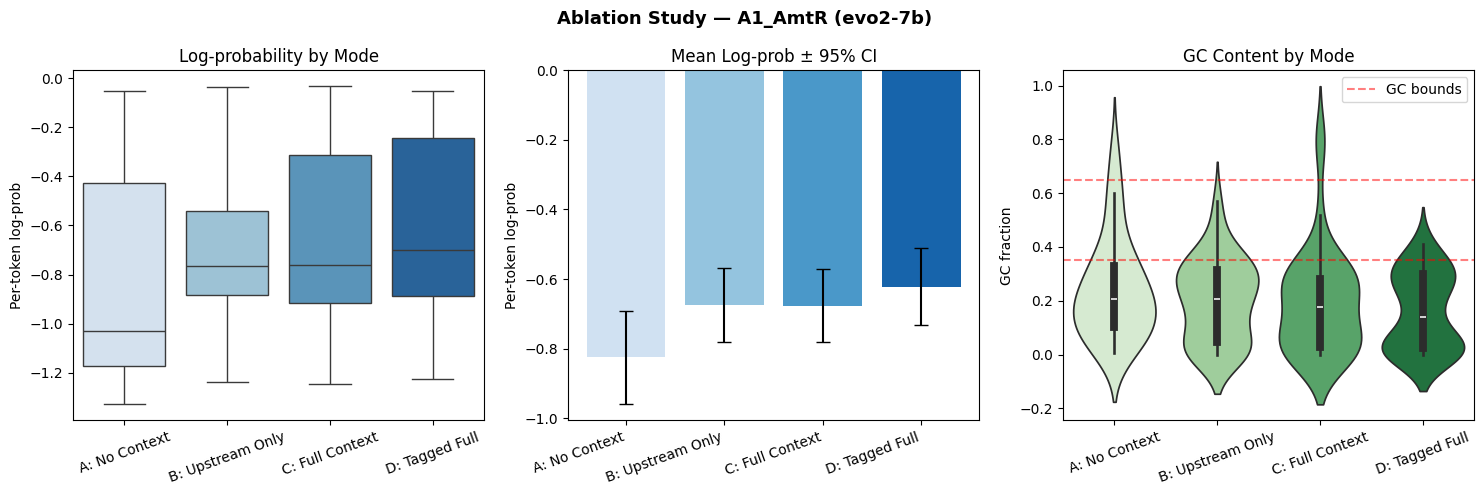

Saved → ../results/ablation/ablation_plot_A1_AmtR.png


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

MODE_ORDER  = [m.value for m in GenerationMode]
MODE_LABELS = ["A: No Context", "B: Upstream Only", "C: Full Context", "D: Tagged Full"]

df_plot = df.copy()
df_plot["mode_label"] = df_plot["mode"].map(dict(zip(MODE_ORDER, MODE_LABELS)))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"Ablation Study — {GATE_NAME} ({NVIDIA_MODEL})", fontsize=13, fontweight="bold")

# Log-prob boxplot
sns.boxplot(data=df_plot, x="mode_label", y="log_prob", order=MODE_LABELS,
            palette="Blues", ax=axes[0])
axes[0].set_title("Log-probability by Mode")
axes[0].set_xlabel("")
axes[0].set_ylabel("Per-token log-prob")
axes[0].tick_params(axis="x", rotation=20)

# Mean ± 95% CI bar chart
means = df_plot.groupby("mode_label")["log_prob"].agg(["mean", "std", "count"]).reindex(MODE_LABELS)
ci95  = 1.96 * means["std"] / np.sqrt(means["count"])
axes[1].bar(range(4), means["mean"], yerr=ci95, capsize=5,
            color=sns.color_palette("Blues", 4))
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(MODE_LABELS, rotation=20, ha="right")
axes[1].set_title("Mean Log-prob ± 95% CI")
axes[1].set_ylabel("Per-token log-prob")

# GC content violin
sns.violinplot(data=df_plot, x="mode_label", y="gc_content", order=MODE_LABELS,
               palette="Greens", ax=axes[2])
axes[2].axhline(0.35, color="red", linestyle="--", alpha=0.5, label="GC bounds")
axes[2].axhline(0.65, color="red", linestyle="--", alpha=0.5)
axes[2].set_title("GC Content by Mode")
axes[2].set_xlabel("")
axes[2].set_ylabel("GC fraction")
axes[2].tick_params(axis="x", rotation=20)
axes[2].legend()

plt.tight_layout()
plot_path = OUTPUT_DIR / f"ablation_plot_{GATE_NAME}.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {plot_path}")

## 8. Statistical Summary

In [40]:
from scipy import stats

print("=" * 65)
print(f"ABLATION RESULTS — {GATE_NAME} — {N_CANDIDATES} candidates/mode ({NVIDIA_MODEL})")
print("=" * 65)

full_summary = df.groupby("mode")["log_prob"].agg(["mean", "std", "median", "count"]).reindex(
    [m.value for m in GenerationMode]
)
full_summary.index = MODE_LABELS
print("\nLog-prob statistics:")
print(full_summary.round(4).to_string())

print("\nPairwise t-tests vs. NO_CONTEXT baseline:")
baseline = df[df["mode"] == GenerationMode.NO_CONTEXT.value]["log_prob"]
for mode in [GenerationMode.UPSTREAM_ONLY, GenerationMode.FULL_CONTEXT, GenerationMode.TAGGED_FULL]:
    group = df[df["mode"] == mode.value]["log_prob"]
    t_stat, p_val = stats.ttest_ind(group, baseline)
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    print(f"  {mode.value:20s} vs no_context:  t={t_stat:+.3f}  p={p_val:.4f}  {sig}")

print("\nHard-filter pass rate by mode (GC 35-65%, length delta ≤ 20bp):")
for mode in [m.value for m in GenerationMode]:
    mode_df   = df[df["mode"] == mode]
    pass_rate = mode_df["gc_in_range"].mean()
    print(f"  {mode:20s}  GC-pass: {pass_rate:.1%}  (n={len(mode_df)})")

ABLATION RESULTS — A1_AmtR — 10 candidates/mode (evo2-7b)

Log-prob statistics:
                    mean     std  median  count
A: No Context    -0.8255  0.4281 -1.0297     40
B: Upstream Only -0.6750  0.3398 -0.7653     40
C: Full Context  -0.6765  0.3410 -0.7626     40
D: Tagged Full   -0.6226  0.3563 -0.6985     40

Pairwise t-tests vs. NO_CONTEXT baseline:
  upstream_only        vs no_context:  t=+1.742  p=0.0855  ns
  full_context         vs no_context:  t=+1.721  p=0.0891  ns
  tagged_full          vs no_context:  t=+2.304  p=0.0239  *

Hard-filter pass rate by mode (GC 35-65%, length delta ≤ 20bp):
  no_context            GC-pass: 20.0%  (n=40)
  upstream_only         GC-pass: 20.0%  (n=40)
  full_context          GC-pass: 5.0%  (n=40)
  tagged_full           GC-pass: 10.0%  (n=40)
